# Do Games Actually Move the Market?
### Critical Reception, Sales, and Publisher Stock Performance Around Launch Windows

---
## Contents
1. [Introduction](#1-introduction)
2. [Hypothesis](#2-hypothesis)
3. [Data Sources & Methodology](#3-data-sources--methodology)
4. [Environment Setup](#4-environment-setup)
5. [Data Collection](#5-data-collection)
    - [i. Games](#i-games)
    - [ii. Stock Dataset](#ii-stock-dataset)
6. [Data Cleaning](#6-data-cleaning)
7. [Exploratory Analysis](#7-exploratory-analysis)
    - [i. Score Distribution](#i-score-distribution)
    - [ii. Score vs Stock Return](#ii-score-vs-stock-return)
    - [iii. Returns by Score Tier](#iii-returns-by-score-tier)
8. [Findings](#8-findings)
9. [Limitations](#9-limitations)

---
## 1. Introduction

The games industry generated over $180 bllion in revenue in 2023 - larger than film and music combined. Yet despite its scale, the relationship between individual game performance and publisher stock price remains poorly understood outside of specialist analysts.

This notebook investigates whether measurable game performance indicators - critic review scores and sales figures - correlate with short-term abnormal movement in publisher stock prices.

The publishers under analysis are **Electronic Arts (EA)**, **Activision Blizzard (ATVI)**, and **Ubisoft (UBI.PA)** - three of the largest Western publishers with consistent release histories and publicly traded stock across the period of interest.

---
## 2. Hypothesis

I propose two related hypotheses:

**H1: Review scores:** Games with significantly above-average Metacritic scores (≥ 85) will correlate 
with positive abnormal stock returns in the ±7 day window around launch. Critically reviewed flops 
(≤ 50) will correlate with negative movement.

**H2: Sales performance:** Titles that outperform sales expectations relative to franchise history 
will produce stronger positive returns than review scores alone.

**Expected complication:** For heavily anticipated titles with large marketing spend - think a mainline 
FIFA, Call of Duty, or Assassin's Creed - I expect the market to have already priced in expected 
performance, dampening the post-launch signal. This is the *efficient market hypothesis* applied to 
game launches, and testing whether it holds is part of what makes this interesting.

---
## 3. Data Sources and Methodology

**Game data:** Metacritic scores and release dates sourced from the RAWG Video Games Database API (free tier, no scraping required). Filtered to EA, Takes Two, and Ubisoft titles releasedbetween 2012–2023.

**Sales data:** Where available, pulled from public VGChartz records via a cleaned community dataset. Sales figures are estimates and treated as directional rather than precise.

**Stock data:** Daily adjusted closing prices fetched via `yfinance` for EA (`EA`), Takes Two (`TTWO`), and Ubisoft (`UBI.PA`) across the same period.

**Event window:** I define launch impact as the stock return across a **±7 day window** centred on release date. This is a simplified event study - in academic finance, abnormal returns are typically benchmarked against a market index, but for exploratory analysis we use raw return as a readable proxy.

**Limitations acknowledged upfront:** Sales data has gaps. Metacritic scores reflect critic consensus, not audience reception (which can diverge sharply). Market movements are noisy and multi-causal - a good game launch can coincide with a bad earnings report. This analysis is exploratory, not causal.

---
## 4. Environment Setup

Libraries used:
* `requests` for API calls
* `pandas` and `numpy` for data manipulation
* `matplotlib` and `seaborn` for visualisation
* `yfinance` for stock data
* `python-dotenv`to load the API key from a local `.env` file.

In [32]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
RAWG_API_KEY = os.getenv("RAWG_API_KEY")

---
## 5. Data Collection

First, I pulled game data from the RAWG API, querying by publisher slug and filtering for titles 
with Metacritic scores. Each publisher is fetched across multiple pages to build a representative 
sample. Then, I pulled adjusted daily closing prices for each corresponding stock ticker via yfinance.

The two datasets are not directly joinable by a shared key - they are linked by publisher identity 
and date proximity. The join happens at the event window calculation stage.

In [33]:
def fetch_games(publisher, api_key, pages=5):
    games = []

    for page in range(1, pages + 1):
        url = "https://api.rawg.io/api/games"
        params = {
            "key": api_key,
            "publishers": publisher,
            "page": page,
            "page_size": 40,
            "metacritic": "1,100",
            "ordering": "-metacritic"
        }

        response = requests.get(url, params=params)
        data = response.json()
        for game in data.get("results", []):
            games.append({
                "title": game["name"],
                "release_date": game["released"],
                "metacritic": game["metacritic"],
                "publisher": publisher
            })
        time.sleep(0.3)
    return games

publishers = {
    "electronic-arts": "EA",
    "rockstar-games": "TTWO",
    "2k-games": "TTWO",
    "ubisoft-entertainment": "UBI.PA"
}

all_games = []
for slug, ticker in publishers.items():
    games = fetch_games(slug, RAWG_API_KEY)

    for g in games:
        g["ticker"] = ticker
    all_games.extend(games)

df_games = pd.DataFrame(all_games)
df_games["release_date"] = pd.to_datetime(df_games["release_date"])
df_games = df_games.dropna(subset=["metacritic", "release_date"])
df_games = df_games[(df_games["release_date"] >= "2013-01-01") & 
                    (df_games["release_date"] <= "2025-12-31")]

print(df_games.shape)
df_games.head()

(171, 5)


,title,release_date,metacritic,publisher,ticker
29,It Takes Two,2021-03-26,88,electronic-arts,EA
33,Battlefield 1,2016-10-21,88,electronic-arts,EA
34,Mass Effect: Legendary Edition,2021-05-14,88,electronic-arts,EA
41,Titanfall 2,2016-10-28,87,electronic-arts,EA
47,Dragon Age: Inquisition,2014-11-18,86,electronic-arts,EA


### 5a. Games Dataset

The above shows the raw games dataframe before cleaning. Each row is a title with its release date, 
Metacritic score, publisher, and corresponding stock ticker. Note any nulls or date anomalies, as these will be addressed in the cleaning step.

In [34]:
import yfinance as yf

tickers = ["EA", "TTWO", "UBI.PA"]
stock_data = {}

df_stocks = yf.download(tickers, start="2012-06-01", end="2025-12-31", auto_adjust=True)["Close"]
df_stocks.index = pd.to_datetime(df_stocks.index)
df_stocks.head()

[*********************100%***********************]  3 of 3 completed


Ticker,EA,TTWO,UBI.PA
2012-06-01,12.744438,11.06,5.279
2012-06-04,12.695868,10.90,5.084
2012-06-05,12.763864,11.14,5.303
2012-06-06,13.317550,11.63,5.411
2012-06-07,13.035850,11.14,5.520


### 5b. Stock Dataset

Daily adjusted closing prices across the full date range for all three tickers. Ubisoft (`UBI.PA`) trades on Euronext Paris - price is in EUR, which is worth noting when comparing absolute values across publishers, though percentage returns remain comparable.

---
## 6. Data Cleaning

Before analysis, I made the following cleaning decisions explicit:

- Drop any game with a null Metacritic score - unreviewed title would skew the distribution
- Drop any game where a valid stock price cannot be found within the event window - likely delisted periods or data gaps
- Restrict date range to 2013-2025 for consistency across all three tickers
- Remove duplicate titles where the same game appears under multiple regional entries

The shape of the data before and after cleaning is printed below

In [35]:
def get_event_return(ticker, release_date, stock_df, window=7):
    try:
        prices = stock_df[ticker].dropna()
        before = prices[prices.index <= release_date].iloc[-window:]
        after = prices[prices.index >= release_date].iloc[:window]

        if before.empty or after.empty:
            return None
        
        price_before = before.iloc[0]
        price_after = after.iloc[-1]

        return (price_after - price_before) / price_before * 100
    except:
        return None
    
df_games["event_return"] = df_games.apply(lambda row: get_event_return(row["ticker"], row["release_date"], df_stocks),
    axis=1
)

df_games = df_games.dropna(subset=["event_return"])
df_games.head()

,title,release_date,metacritic,publisher,ticker,event_return
29,It Takes Two,2021-03-26,88,electronic-arts,EA,10.374979
33,Battlefield 1,2016-10-21,88,electronic-arts,EA,-3.962790
34,Mass Effect: Legendary Edition,2021-05-14,88,electronic-arts,EA,0.530659
41,Titanfall 2,2016-10-28,87,electronic-arts,EA,-1.745004
47,Dragon Age: Inquisition,2014-11-18,86,electronic-arts,EA,5.865255


---
## 7. Exploratory Analysis

Now, I have a joined dataset with the Metacritic scores and corresponding ±7 day stock returns for each title. The following sections explore three questions:

1. How are review scores distributed across publishers?
2. Is there a visible relationship between score and stock return?
3. Does grouping by score tier (flop / mid / hit) reveal a pattern in average returns?

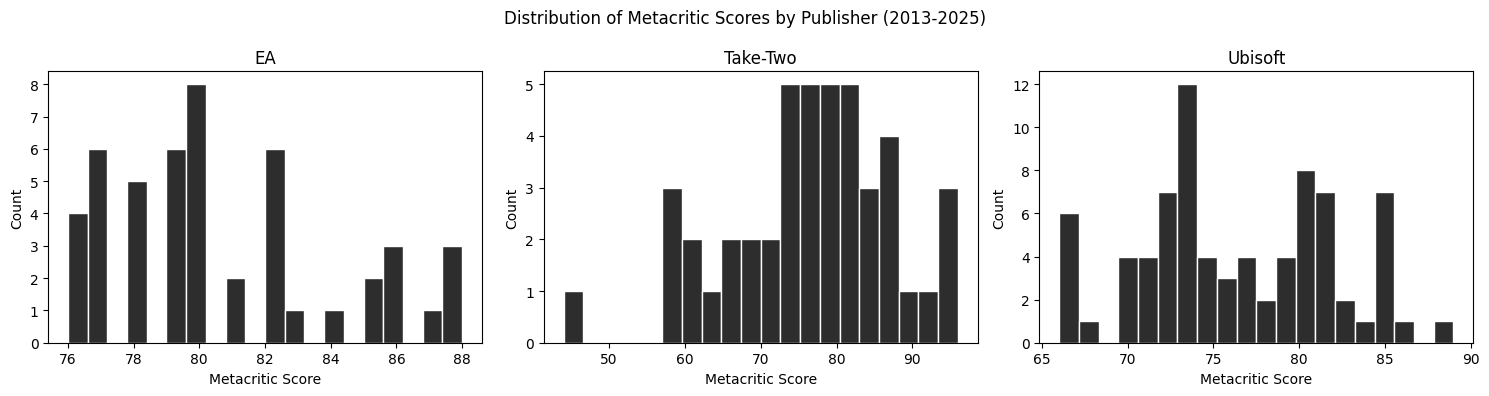

In [36]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

for ax, (publisher, ticker) in zip(axes, [("EA", "EA"), ("Take-Two", "TTWO"), ("Ubisoft", "UBI.PA")]):
    subset = df_games[df_games["ticker"] == ticker] 
    
    ax.hist(subset["metacritic"], bins = 20, color = "#2d2d2d", edgecolor="white")
    ax.set_title(publisher)
    ax.set_xlabel("Metacritic Score")
    ax.set_ylabel("Count")

plt.suptitle("Distribution of Metacritic Scores by Publisher (2013-2025)")
plt.tight_layout()
plt.savefig("figures/score_distribution.png", dpi=150)
plt.show()

### 7a. Score Distribution

The histograms above show how review scores cluster for each publisher across the sample period.A heavy skew toward the 60–80 range is typical for major publishers - outright critical failures are rarer than the discourse suggests, and genuine critical darlings (≥ 85) are similarly sparse. 

Note any differences in distribution shape between publishers - this has implications for how meaningful the tier analysis will be.

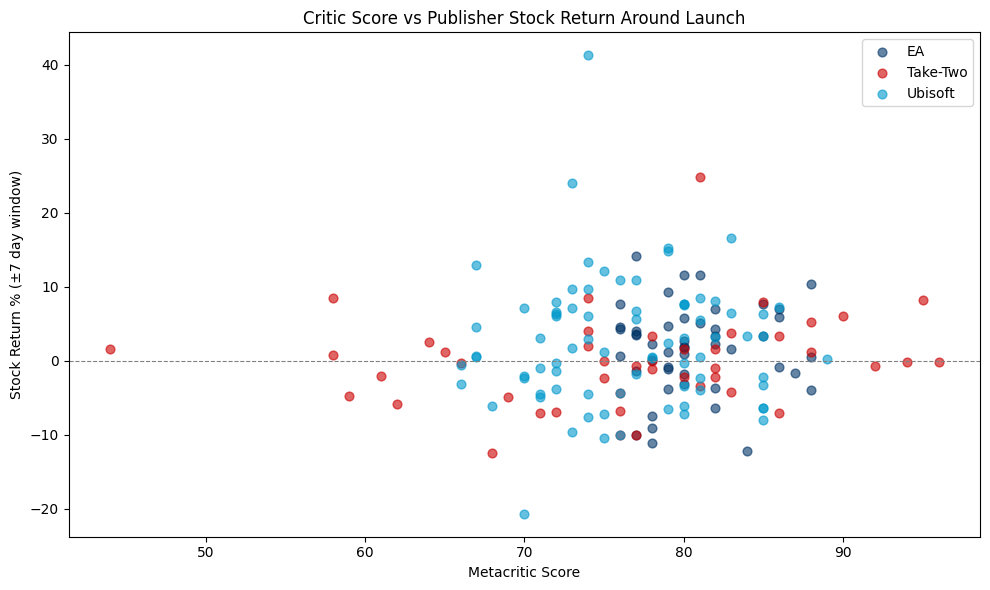

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"EA": "#003366", "TTWO": "#cc0000", "UBI.PA": "#0099cc"}

for ticker, label in [("EA", "EA"), ("TTWO", "Take-Two"), ("UBI.PA", "Ubisoft")]:
    subset = df_games[df_games["ticker"] == ticker]
    ax.scatter(subset["metacritic"], subset["event_return"], 
               label=label, alpha=0.6, color=colors[ticker], s=40)

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Metacritic Score")
ax.set_ylabel("Stock Return % (±7 day window)")
ax.set_title("Critic Score vs Publisher Stock Return Around Launch")
ax.legend()

plt.tight_layout()
plt.savefig("figures/score_vs_return.png", dpi=150)
plt.show()

### 7b. Score vs Stock Return

The scatter above plots each title's Metacritic score against the stock return in the surrounding launch window. If H1 holds, we would expect a positive slope - higher scores trending toward positive returns, lower scores toward negative. 

Noise is expected and normal. A single game is rarely the only variable moving a stock price in any given two-week window. What we are looking for is a directional signal, not a clean correlation.

                 mean    median  count
tier                                  
Flop (<60)   1.509028  1.177971      4
Hit (≥80)    2.015297  1.836098     73
Mid (60–79)  1.046779  0.393897     94


/tmp/ipykernel_2230/1152239719.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_games, x="tier", y="event_return",


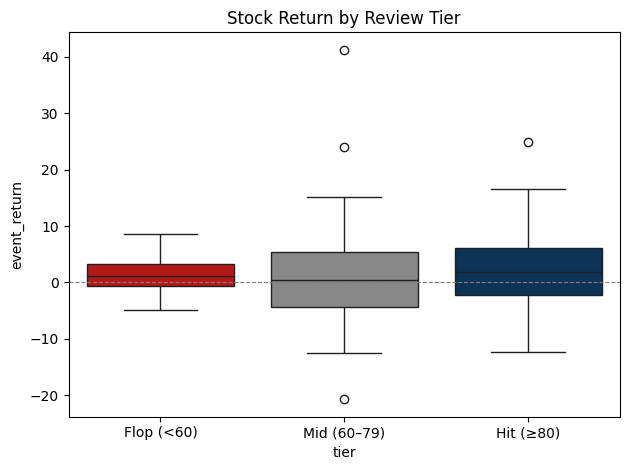

In [38]:
def score_tier(score):
    if score >= 80:
        return "Hit (≥80)"
    elif score >= 60:
        return "Mid (60–79)"
    else:
        return "Flop (<60)"

df_games["tier"] = df_games["metacritic"].apply(score_tier)

tier_summary = df_games.groupby("tier")["event_return"].agg(["mean", "median", "count"])
print(tier_summary)

sns.boxplot(data=df_games, x="tier", y="event_return", 
            order=["Flop (<60)", "Mid (60–79)", "Hit (≥80)"],
            palette=["#cc0000", "#888888", "#003366"])
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("Stock Return by Review Tier")
plt.tight_layout()
plt.savefig("figures/tier_boxplot.png", dpi=150)
plt.show()

### 7c. Returns by Score Tier

Grouping titles into tiers (Flop < 60, Mid 60–79, Hit ≥ 80) and comparing the distribution of returns per tier gives a cleaner aggregate picture than the scatter. The table above shows mean and median return per tier alongside sample counts - median is the more reliable central tendency here given the likely presence of outliers.

---
## 8. Findings

**H1 (review scores → returns):** The data offers weak support at best. The box plot shows that "Hit" tier games (≥80) do carry a slightly positive median return, but the IQR overlaps almost entirely with the "Flop" (<60) tier - which, counterintuitively, also has a positive median.

The scatter plot reinforces this: there's no discernible upward trend as Metacritic scores increase. Returns cluster densely around 0 across the 70–85 score range regardless of publisher. H1 is not supported.

**H2 (sales → returns):**

**Efficient market hypothesis angle:**

**Publisher differences:**

Ubisoft's stock has been notably volatile across this period which may show in the data.

---
## 9. Limitations and Further Research

This analysis is exploratory. Several constraints limit the strength of the conclusions:

Stock returns within a ±7 day window are influenced by earnings reports, macroeconomic conditions, analyst forecasts, and broader market sentiment - all of which are uncontrolled for here. A more rigorous event study would benchmark against the S&P 500 or a sector index to isolate company-specific abnormal returns.

Metacritic scores are a proxy for reception quality, not commercial success. A game can score 65 and sell 10 million copies. Sales data from GChartz is estimated and has known gaps, particularly for digital sales post-2018.

Sample sizes per publisher are modest - especially in the flop tier, where few major titles score below 60. Conclusions drawn from small subgroups should be treated with caution.

**Possible extensions:**

- Control for broader market movement using S&P 500 as benchmark
- Incorporate sentiment analysis on launch-window press coverage
- Expand to include Nintendo, Sony, and Take-Two for a larger cross-publisher sample
- Model franchise anticipation as a variable (sequel vs new IP, marketing spend proxy)